In [1]:
import xarray as xr

In [2]:
import os
import re
import subprocess
import xarray as xr
import numpy as np
import optuna
import json
import shutil
from multiprocessing import Pool

# ==============================
# 0. SETTINGS
# ==============================
locations = [
    "patch_1", "patch_2", "patch_3", "patch_4", "patch_5",
    "patch_6", "patch_7", "patch_8", "patch_9", "patch_10"
]

BASE_CONFIG_DIR = "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree"
LPJ_BIN = "/home/druijsch/LPJmL5/dev15oct2025/install/bin/lpjml"
OUTPUT_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_needleleaved_evergreen_tree"
os.environ["LPJROOT"] = "/home/druijsch/LPJmL5/dev15oct2025"
TOTAL_CORES = 512

START_YEAR = 2000
END_YEAR   = 2019

# ==============================
# 1. Observations
# ==============================
obs_spei = xr.open_dataset(
    "/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc"
)["SPEI"]

S_obs_mort = -0.46
intercept_mort = -1.96

S_obs_gpp_water = {0:0.14,1:0.12,2:0.12,3:0.17,4:0.18,5:0.08,6:0.08,7:0.10}
intercept_gpp = {0:0.02,1:0.03,2:0.02,3:0.04,4:0.04,5:0.01,6:0.00,7:0.01}

# ==============================
# 2. Utilities
# ==============================
def standardized_anomalies(data):
    data_ref = data.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m)/s if s!=0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

# ==============================
# 3. LPJ parameter modification
# ==============================
pfts = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree"
]

N_OBJECTIVES = 16


/home/druijsch/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load SPEI once
spei = obs_spei.sel(
    time=slice(f"{START_YEAR}", f"{END_YEAR}")
)#.resample(time='MS').mean()
spei

<xarray.DataArray 'SPEI' (time: 240, lat: 1800, lon: 3600)> Size: 12GB
[1555200000 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2019-12-01
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    scipy_dist:  fisk
    method:      ML
    group:       time.month

In [4]:
def compute_gpp_objectives(trial_number):
    trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial_number:04d}")

    gpp_vals = {pft: [] for pft in range(8)}
    spei_vals = {pft: [] for pft in range(8)}

    # Prepare SPEI once
    spei_local = obs_spei.sel(
        time=slice(f"{START_YEAR}", f"{END_YEAR}")
    )#.resample(time='MS').mean()

    for loc in locations:
        out = os.path.join(trial_base, loc, "output")

        gpp = xr.open_dataset(os.path.join(out, "pft_gpp.nc")).GPP \
            .convert_calendar("standard") \
            .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
            .resample(time='MS').mean()

        fpc = xr.open_dataset(os.path.join(out, "fpc.nc")).FPC[:, 1:] \
            .convert_calendar("standard") \
            .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
            .resample(time='MS').mean()

        fpc['pft'] = fpc.pft - 1

        fpc_safe = fpc.where(fpc > 1e-5)
        gpp_per_fpc = gpp / fpc_safe

        gpp_std = standardized_anomalies(gpp_per_fpc)

        spei_loc = spei_local.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

        spei_flat = spei_loc.values.flatten()

        for pft_idx in range(8):
            gpp_flat = gpp_std.isel(pft=pft_idx).values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)

            gpp_vals[pft_idx].append(gpp_flat[mask])
            spei_vals[pft_idx].append(spei_flat[mask])

    # ==============================
    # Compute slopes
    # ==============================
    slopes = {}
    objectives = []

    for pft_idx in range(8):
        gpp_all = np.concatenate(gpp_vals[pft_idx])
        spei_all = np.concatenate(spei_vals[pft_idx])

        mask = np.isfinite(gpp_all) & np.isfinite(spei_all)

        if mask.sum() > 10:
            S_fit, b_fit = np.polyfit(spei_all[mask], gpp_all[mask], 1)

            slopes[pft_idx] = {"slope": S_fit, "intercept": b_fit}

            y_model = S_fit * spei_all[mask] + b_fit
            y_obs = (
                S_obs_gpp_water[pft_idx] * spei_all[mask]
                + intercept_gpp[pft_idx]
            )

            rmse = np.sqrt(np.mean((y_model - y_obs) ** 2))
            objectives.append(rmse)

        else:
            slopes[pft_idx] = {"slope": np.nan, "intercept": np.nan}
            objectives.append(1e6)

    return slopes, objectives

compute_gpp_objectives(0)

/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

({0: {'slope': np.float64(0.0944754823698307),
   'intercept': np.float64(0.02228906481906035)},
  1: {'slope': np.float64(0.1893116860332479),
   'intercept': np.float64(0.05104314331559791)},
  2: {'slope': np.float64(0.5241765876215135),
   'intercept': np.float64(0.11316041008461154)},
  3: {'slope': np.float64(0.3601301637567916),
   'intercept': np.float64(0.16941927575150492)},
  4: {'slope': nan, 'intercept': nan},
  5: {'slope': nan, 'intercept': nan},
  6: {'slope': nan, 'intercept': nan},
  7: {'slope': nan, 'intercept': nan}},
 [np.float64(0.046533426477149434),
  np.float64(0.0677364641341428),
  np.float64(0.39076184719739165),
  np.float64(0.19868221369360486),
  1000000.0,
  1000000.0,
  1000000.0,
  1000000.0])

In [6]:
def compute_mortality_objectives(trial_number):
    trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial_number:04d}")

    mort_vals = {pft: [] for pft in range(8)}
    spei_vals = {pft: [] for pft in range(8)}

    spei_local = obs_spei.sel(
        time=slice(f"{START_YEAR}", f"{END_YEAR}")
    ).resample(time='YS').mean()

    for loc in locations:
        out = os.path.join(trial_base, loc, "output")

        mort = xr.open_dataset(os.path.join(out, "pft_mort.nc")).mortality \
            .convert_calendar("standard") \
            .sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")) \
            .resample(time="YS").sum()

        spei_loc = spei_local.sel(lat=mort.lat, lon=mort.lon, method="nearest")

        spei_flat = spei_loc.values.flatten()

        for pft_idx in range(8):
            mort_flat = mort.isel(pft=pft_idx).values.flatten()

            # log transform
            mort_flat = np.log10(mort_flat)

            mask = np.isfinite(mort_flat) & np.isfinite(spei_flat)

            mort_vals[pft_idx].append(mort_flat[mask])
            spei_vals[pft_idx].append(spei_flat[mask])

    # ==============================
    # Compute slopes
    # ==============================
    slopes = {}
    objectives = []

    for pft_idx in range(8):
        mort_all = np.concatenate(mort_vals[pft_idx])
        spei_all = np.concatenate(spei_vals[pft_idx])

        mask = np.isfinite(mort_all) & np.isfinite(spei_all)

        if mask.sum() > 10:
            S_fit, b_fit = np.polyfit(spei_all[mask], mort_all[mask], 1)

            slopes[pft_idx] = {"slope": S_fit, "intercept": b_fit}

            y_model = S_fit * spei_all[mask] + b_fit
            y_obs = S_obs_mort * spei_all[mask] + intercept_mort

            rmse = np.sqrt(np.mean((y_model - y_obs) ** 2))
            objectives.append(rmse)

        else:
            slopes[pft_idx] = {"slope": np.nan, "intercept": np.nan}
            objectives.append(1e6)

    return slopes, objectives

compute_mortality_objectives(0)

/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)
/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)
/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)
/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)
/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)
/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)
/scratch-local/77370/ipykernel_4043065/1401912551.py:27: RuntimeWarning: divide by zero encountered in log10
  mort_flat = np.log10(mort_flat)

({0: {'slope': np.float64(-0.10174157207450552),
   'intercept': np.float64(-2.040051917596337)},
  1: {'slope': np.float64(-0.10230116047107342),
   'intercept': np.float64(-2.083114057053826)},
  2: {'slope': np.float64(-0.19900846070956926),
   'intercept': np.float64(-2.2071329968647864)},
  3: {'slope': np.float64(-0.19675817035518856),
   'intercept': np.float64(-2.122852975799824)},
  4: {'slope': nan, 'intercept': nan},
  5: {'slope': nan, 'intercept': nan},
  6: {'slope': nan, 'intercept': nan},
  7: {'slope': nan, 'intercept': nan}},
 [np.float64(0.3523574400109948),
  np.float64(0.37393328195415204),
  np.float64(0.39214301131999074),
  np.float64(0.3748028117236707),
  1000000.0,
  1000000.0,
  1000000.0,
  1000000.0])

<xarray.DataArray 'GPP' (time: 720, pft: 43, lat: 9, lon: 7)> Size: 8MB
[1950480 values with dtype=float32]
Coordinates:
  * time     (time) object 6kB 1960-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 172B 1 2 3 4 5 6 7 8 9 ... 35 36 37 38 39 40 41 42 43
  * lat      (lat) float64 72B -15.25 -15.15 -15.05 ... -14.65 -14.55 -14.45
  * lon      (lon) float64 56B -40.25 -40.15 -40.05 -39.95 -39.85 -39.75 -39.65
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

In [13]:
gpp 

<xarray.DataArray 'GPP' (time: 720, pft: 43, lat: 9, lon: 7)> Size: 8MB
[1950480 values with dtype=float32]
Coordinates:
  * time     (time) object 6kB 1960-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 172B 1 2 3 4 5 6 7 8 9 ... 35 36 37 38 39 40 41 42 43
  * lat      (lat) float64 72B -15.25 -15.15 -15.05 ... -14.65 -14.55 -14.45
  * lon      (lon) float64 56B -40.25 -40.15 -40.05 -39.95 -39.85 -39.75 -39.65
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

In [15]:
fpc

<xarray.DataArray 'FPC' (time: 720, pft: 11, lat: 9, lon: 7)> Size: 2MB
array([[[[0.901434, ..., 0.877755],
         ...,
         [0.869044, ..., 0.848242]],

        ...,

        [[0.      , ..., 0.      ],
         ...,
         [0.      , ..., 0.      ]]],


       ...,


       [[[0.875438, ..., 0.894192],
         ...,
         [0.874324, ..., 0.811471]],

        ...,

        [[0.      , ..., 0.      ],
         ...,
         [0.      , ..., 0.      ]]]], shape=(720, 11, 9, 7), dtype=float32)
Coordinates:
  * time     (time) object 6kB 1960-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 44B 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 72B -15.25 -15.15 -15.05 ... -14.65 -14.55 -14.45
  * lon      (lon) float64 56B -40.25 -40.15 -40.05 -39.95 -39.85 -39.75 -39.65
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [24]:
trial_number = 0
trial_base = os.path.join(OUTPUT_DIR, f"trial_{trial_number:04d}")

# Prepare storage per PFT
gpp_vals = {pft: [] for pft in range(8)}
spei_vals = {pft: [] for pft in range(8)}



for loc in locations:
    print(loc)
    out = os.path.join(trial_base, loc, "output")


    gpp = xr.open_dataset(os.path.join(out, "pft_gpp.nc")).GPP.convert_calendar("standard").sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")).resample(time = 'MS').mean()
    fpc = xr.open_dataset(os.path.join(out, "fpc.nc")).FPC[:, 1:].convert_calendar("standard").sel(time=slice(f"{START_YEAR}", f"{END_YEAR}")).resample(time = 'MS').mean()
    fpc['pft'] = fpc.pft - 1

    # Avoid division by zero
    fpc_safe = fpc.where(fpc > 1e-5)
    gpp_per_fpc = gpp / fpc_safe

    # Standardize
    gpp_std = standardized_anomalies(gpp_per_fpc)

    # Match SPEI to grid
    spei_loc = spei.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")

    # Loop over PFTs
    for pft_idx in range(8):
        print(pft_idx)
        gpp_pft = gpp_std.isel(pft=pft_idx).values.flatten()
        spei_pft = spei_loc.values.flatten()

        mask = np.isfinite(gpp_pft) & np.isfinite(spei_pft)

        gpp_vals[pft_idx].append(gpp_pft[mask])
        spei_vals[pft_idx].append(spei_pft[mask])





patch_1


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

0
1
2
3
4
5
6
7
patch_2


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

0
1
2
3
4
5
6
7
patch_3


...

0
1
2
3
4
5
6
7
patch_9


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

0
1
2
3
4
5
6
7
patch_10


/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/druijsch/myenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

0
1
2
3
4
5
6
7


In [25]:
# ==============================
# Compute slopes
# ==============================
slopes = {}
objectives = []

for pft_idx in range(8):
    print(pft_idx)
    gpp_all = np.concatenate(gpp_vals[pft_idx])
    spei_all = np.concatenate(spei_vals[pft_idx])

    mask = np.isfinite(gpp_all) & np.isfinite(spei_all)

    if mask.sum() > 10:
        S_fit, b_fit = np.polyfit(spei_all[mask], gpp_all[mask], 1)

        slopes[pft_idx] = {"slope": S_fit, "intercept": b_fit}

        # Compare to observed relationship
        y_model = S_fit * spei_all[mask] + b_fit
        y_obs = (
            S_obs_gpp_water[pft_idx] * spei_all[mask]
            + intercept_gpp[pft_idx]
        )

        rmse = np.sqrt(np.mean((y_model - y_obs) ** 2))
        objectives.append(rmse)

        print(f"PFT {pft_idx}: slope={S_fit:.3f}, RMSE={rmse:.3f}")

    else:
        slopes[pft_idx] = {"slope": np.nan, "intercept": np.nan}
        objectives.append(1e6)
        print(f"PFT {pft_idx}: insufficient data")


0
PFT 0: slope=0.094, RMSE=0.047
1
PFT 1: slope=0.189, RMSE=0.068
2
PFT 2: slope=0.524, RMSE=0.391
3
PFT 3: slope=0.360, RMSE=0.199
4
PFT 4: insufficient data
5
PFT 5: insufficient data
6
PFT 6: insufficient data
7
PFT 7: insufficient data


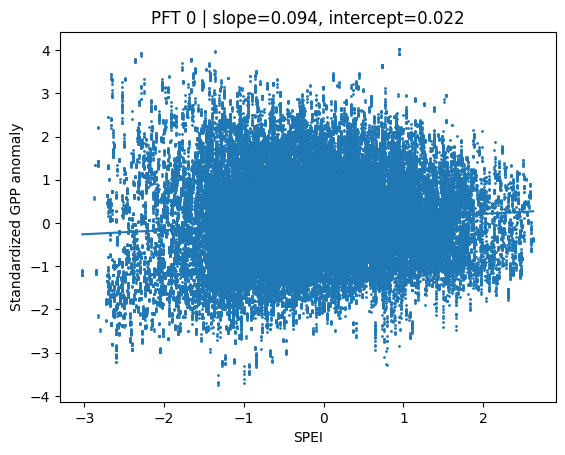

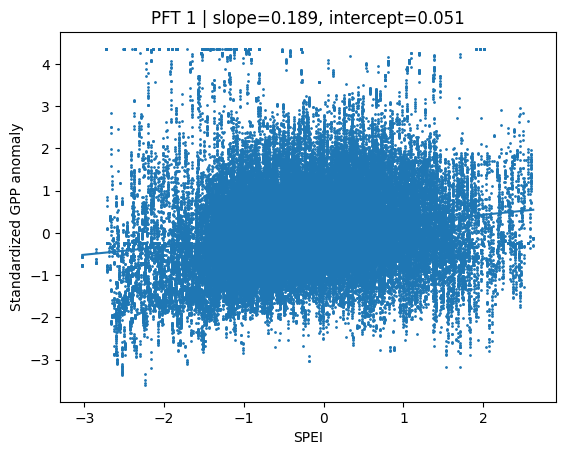

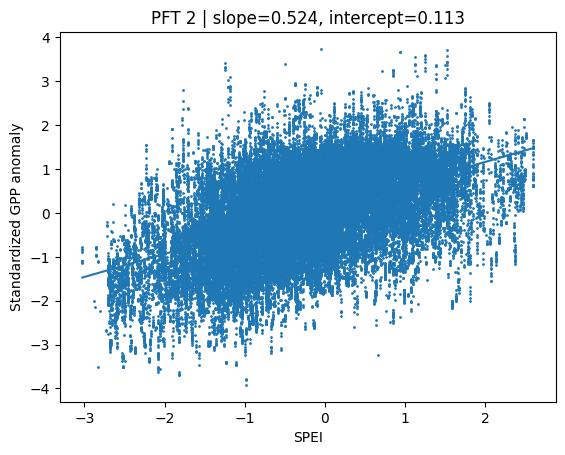

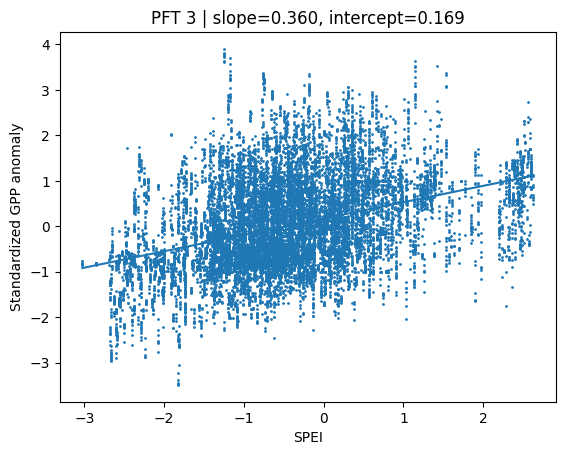

In [26]:
import matplotlib.pyplot as plt
import numpy as np

for pft_idx in range(8):
    gpp_all = np.concatenate(gpp_vals[pft_idx])
    spei_all = np.concatenate(spei_vals[pft_idx])

    mask = np.isfinite(gpp_all) & np.isfinite(spei_all)

    if mask.sum() > 10:
        x = spei_all[mask]
        y = gpp_all[mask]

        S_fit, b_fit = np.polyfit(x, y, 1)

        plt.figure()
        plt.scatter(x, y, s=1)

        # regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = S_fit * x_line + b_fit
        plt.plot(x_line, y_line)

        plt.title(f"PFT {pft_idx} | slope={S_fit:.3f}, intercept={b_fit:.3f}")
        plt.xlabel("SPEI")
        plt.ylabel("Standardized GPP anomaly")

        plt.show()